In [1]:
import rasterio
import numpy as np

tif_path = "/content/drive/MyDrive/GitHub/no2_prediction_pipeline/data/GEE_Surgut_NO2/Surgut_NO2_FebApr_2019_2024.tif"  # подставь свой файл

with rasterio.open(tif_path) as src:
    arr = src.read(1)
    profile = src.profile
    nodata = src.nodata

print("Размер:", arr.shape)
print("dtype:", arr.dtype)
print("nodata:", nodata)

# Маска валидных значений
if nodata is not None:
    valid = arr[arr != nodata]
else:
    valid = arr[~np.isnan(arr)]

print("Число валидных пикселей:", valid.size)
print("Min:", valid.min())
print("Max:", valid.max())
print("Mean:", valid.mean())
print("Std:", valid.std())

Размер: (101, 208)
dtype: float64
nodata: None
Число валидных пикселей: 16459
Min: 1.3537414220052836e-05
Max: 6.340040783624142e-05
Mean: 2.6167339093902285e-05
Std: 7.593433751993663e-06


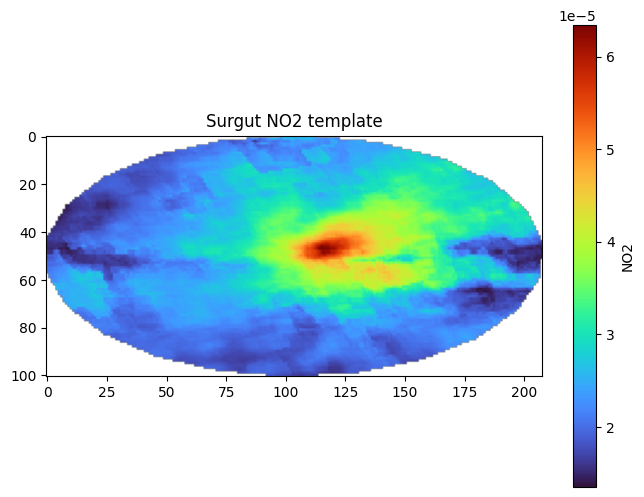

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(arr, cmap="turbo")
plt.colorbar(label="NO2")
plt.title("Surgut NO2 template")
plt.show()

In [7]:
import rasterio
import numpy as np

input_tif = "/content/drive/MyDrive/GitHub/no2_prediction_pipeline/data/GEE_Surgut_NO2/Surgut_NO2_SepNov_2019_2024.tif"
output_tif = "Surgut_NO2_SepNov_template_normalized.tif"

with rasterio.open(input_tif) as src:
    arr = src.read(1).astype("float32")
    profile = src.profile.copy()

# Маска только для нормальных чисел
mask = np.isfinite(arr)

print("Всего пикселей:", arr.size)
print("Валидных пикселей:", mask.sum())

mean_val = arr[mask].mean()
print("Среднее:", mean_val)

# Создаем новый массив
norm_arr = np.full(arr.shape, np.nan, dtype="float32")
norm_arr[mask] = arr[mask] / mean_val

profile.update(dtype="float32")

with rasterio.open(output_tif, "w", **profile) as dst:
    dst.write(norm_arr, 1)

print("Сохранено:", output_tif)
print("Min:", np.nanmin(norm_arr))
print("Max:", np.nanmax(norm_arr))
print("Mean:", np.nanmean(norm_arr))

Всего пикселей: 21008
Валидных пикселей: 16459
Среднее: 1.9875386e-05
Сохранено: Surgut_NO2_SepNov_template_normalized.tif
Min: 0.6281092
Max: 2.3395762
Mean: 1.0
